# Mushroom Classification
## Description:

There are thousands of different species of mushroom, and many of them are inedible and difficult to identify. Here, we aim to find a method to identify edibility by training and examining 3 different machine learning models on the task of classifying whether a mushroom is edible or not based on a set of physical and nonphysical features such as cap dimensions and odor. We are going to use Decision Trees, Adaboost, and Random forest to predict mushroom edibility and then compare the advantages and disadvantages of each model.



## Contribution:

- Xander Boosinger: Initial rough draft, which was largely formatting, cleaning the data of missing values, and applying one-hot-encoding to all non-numeric features (all of them).
- Zach Rojas: Problem discription, feature distribution visualization and analysis, and dataset description.
- Kyle Nguyen: Added a check for constant columns, raw dataset class-balance. Compared encoded dataset shapes across preprocessing versions. Set up helpers or future proofing.


### Part 1: Data Preprocessing

* #### Initial Exploration

The dataset we are using is the UCI Mushroom dataset.  
"Mushroom," UCI Machine Learning Repository, 1981. [Online]. Available: https://doi.org/10.24432/C5959T.

1. Dataset description

In [2]:
#%matplotlib widget
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pandas
import seaborn as seaborn
import matplotlib.pyplot as pyplot
import numpy as numpy
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

import pandas as pd



df = pandas.read_csv('../data/expanded_csv.csv')
df = df.replace('?', numpy.nan)

pandas.set_option('display.max_colwidth', 20)
pandas.set_option('display.width', 1000)
pandas.set_option('display.max_columns', 10)
pandas.set_option('display.max_rows', None)

print("Dimensions:")
print(df.shape)
print("")

print("Info:")
print(df.info())
print("")

print("Describe:")
print(df.describe())
print("")

print("Head:")
print(df.head(5))
print("")



Dimensions:
(8416, 23)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8416 entries, 0 to 8415
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Edibility              8416 non-null   object
 1   CapShape               8416 non-null   object
 2   CapSurface             8416 non-null   object
 3   CapColor               8416 non-null   object
 4   Bruises                8416 non-null   object
 5   Odor                   8416 non-null   object
 6   GillAttachment         8416 non-null   object
 7   GillSpacing            8416 non-null   object
 8   GillSize               8416 non-null   object
 9   GillColor              8416 non-null   object
 10  StalkShape             8416 non-null   object
 11  StalkRoot              5936 non-null   object
 12  StalkSurfaceAboveRing  8416 non-null   object
 13  StalkSurfaceBelowRing  8416 non-null   object
 14  StalkColorAboveRing    8416 non-null   obj

The dataset has 8,416 samples and 23 features with edibility being the target variable. An important characteristic of this dataset is that it is entirely categorical data with no numerical or continuous data, which will affect the preprocessing as we will need to be able to encode the dataset into numerical values.

### Raw Dataset Class Balance

In [3]:
print("Overall Edibility Counts:")
print(df["Edibility"].value_counts())
print()
print("Overall Edibility Proportions:")
print(df["Edibility"].value_counts(normalize=True))

Overall Edibility Counts:
Edibility
EDIBLE       4488
POISONOUS    3928
Name: count, dtype: int64

Overall Edibility Proportions:
Edibility
EDIBLE       0.53327
POISONOUS    0.46673
Name: proportion, dtype: float64


### Feature Distributions

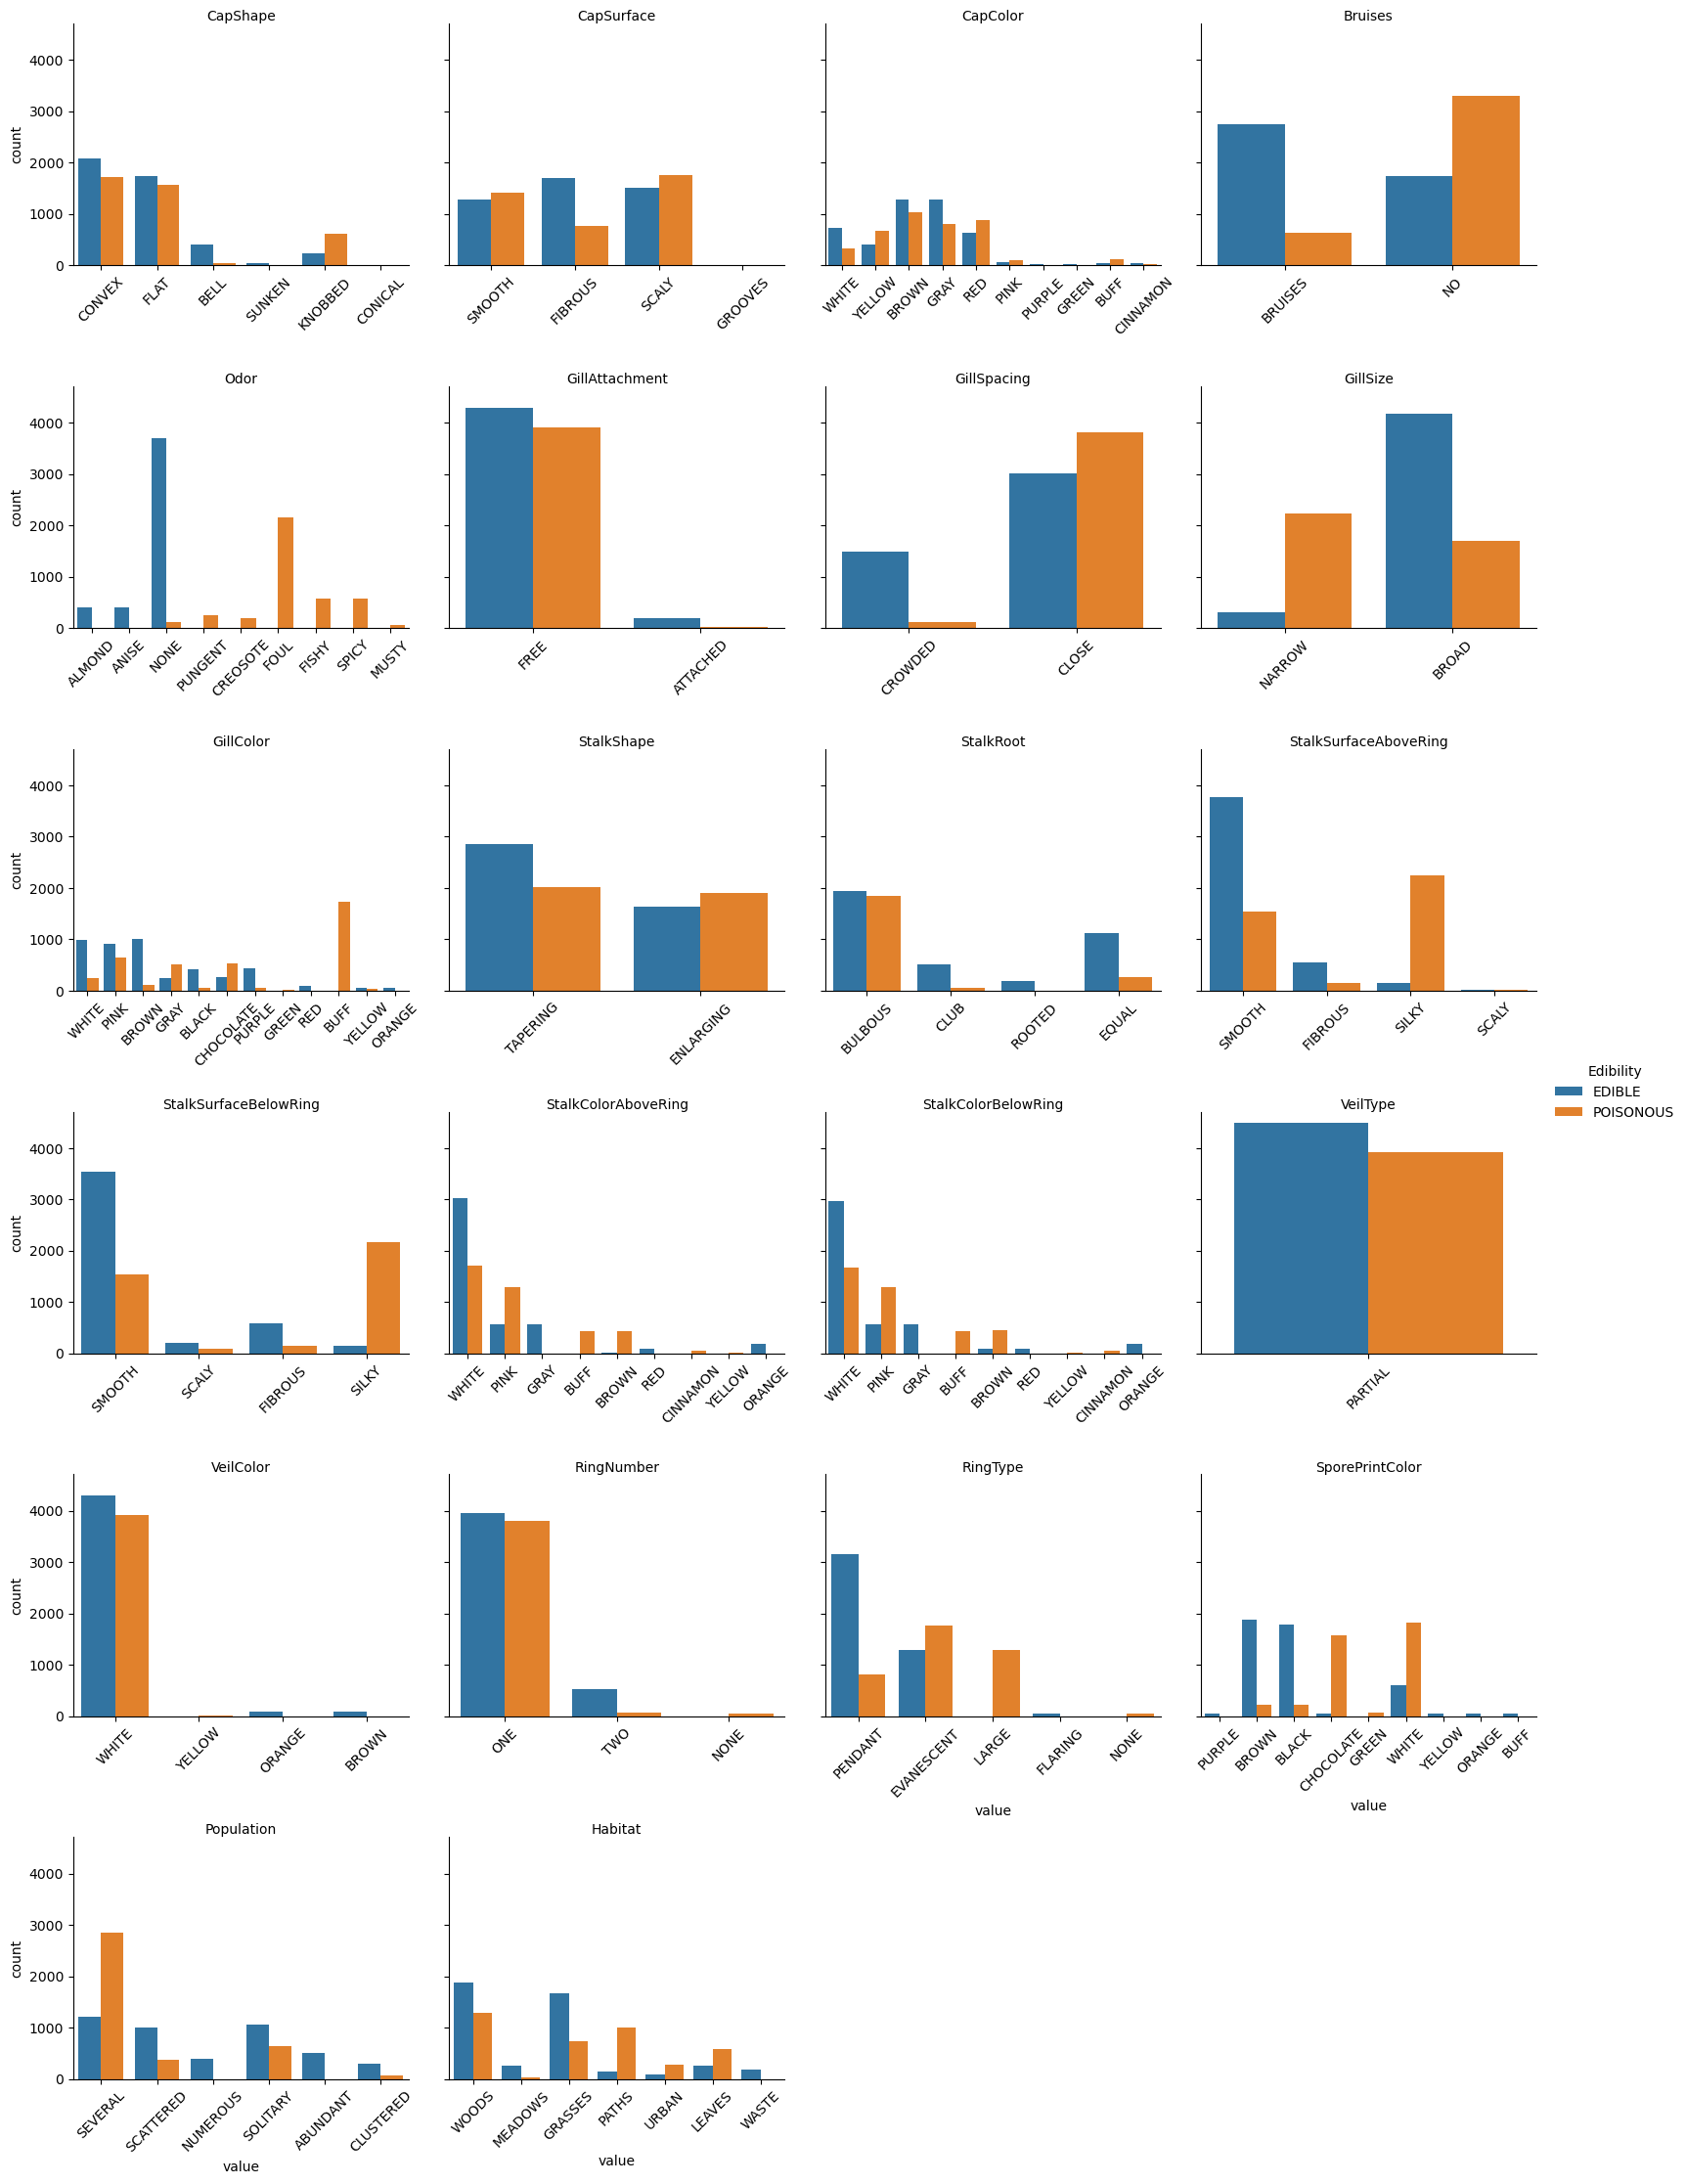

In [4]:

features = df.drop("Edibility", axis=1)

df_melted = df.melt(id_vars='Edibility', value_vars=features.columns)

plot = seaborn.catplot(
    data=df_melted,
    hue='Edibility',
    col='variable',
    kind='count',
    x='value',
    col_wrap=4,
    sharex=False,
    height=4,
)
plot.set_xticklabels(rotation=45)
plot.set_titles("{col_name}", pad=-20)
plot.figure.subplots_adjust(top=0.9, hspace=0.5)

pyplot.show()

Here we can see the distributions of each feature relative to its edibility. For example, for the RingNumber feature, most of the samples have only 1 ring, and there are about an equal number of edible and poisonous mushrooms with one ring. However, mushrooms with two rings are mostly edible. Another insight we can gather from this visualization is based on the odor feature. Mushrooms with an almond, anise, or no odor, are almost entirely edible, while mushrooms with other odors are mostly poisonous. We can see similar patterns across other features as well, such as with the Bruizes, StalkSurfaceAboveRing, GillColor, GillSize and RingType features, which have some of the largest differences in ratios of edible and poisonous based on the value of these features. 

2. Check for missing values in every column.

In [5]:
print("Null Value Counts:")
print(df.isnull().sum())
print("")

Null Value Counts:
Edibility                   0
CapShape                    0
CapSurface                  0
CapColor                    0
Bruises                     0
Odor                        0
GillAttachment              0
GillSpacing                 0
GillSize                    0
GillColor                   0
StalkShape                  0
StalkRoot                2480
StalkSurfaceAboveRing       0
StalkSurfaceBelowRing       0
StalkColorAboveRing         0
StalkColorBelowRing         0
VeilType                    0
VeilColor                   0
RingNumber                  0
RingType                    0
SporePrintColor             0
Population                  0
Habitat                     0
dtype: int64



3. For each column that has missing values, decide how to handle it.

In [6]:
dfnullsdropped = df.drop(["StalkRoot"], axis=1)
dfnullsfilled = df.copy()
dfnullsfilled.fillna({"StalkRoot": "UNKNOWN"}, inplace=True)

To help analyze the impact of different preprocessing strategies, We are making multiple versions of the dataset; dfnullsdropped for dropping the features with missing values wholesale, and dfnullsfilled for replacing the null values with a new "unknown" value for the features in question. In this case, the only feature which has missing values is StalkRoot. Additionally, removing the records with missing values isn't a viable option at all, because we'd be losing a quarter of the dataset despite only about 1% of the overall data missing.

In [7]:
print("Unique values per raw feature:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].dropna().unique())}")

Unique values per raw feature:
Edibility: 2 unique values -> ['EDIBLE', 'POISONOUS']
CapShape: 6 unique values -> ['BELL', 'CONICAL', 'CONVEX', 'FLAT', 'KNOBBED', 'SUNKEN']
CapSurface: 4 unique values -> ['FIBROUS', 'GROOVES', 'SCALY', 'SMOOTH']
CapColor: 10 unique values -> ['BROWN', 'BUFF', 'CINNAMON', 'GRAY', 'GREEN', 'PINK', 'PURPLE', 'RED', 'WHITE', 'YELLOW']
Bruises: 2 unique values -> ['BRUISES', 'NO']
Odor: 9 unique values -> ['ALMOND', 'ANISE', 'CREOSOTE', 'FISHY', 'FOUL', 'MUSTY', 'NONE', 'PUNGENT', 'SPICY']
GillAttachment: 2 unique values -> ['ATTACHED', 'FREE']
GillSpacing: 2 unique values -> ['CLOSE', 'CROWDED']
GillSize: 2 unique values -> ['BROAD', 'NARROW']
GillColor: 12 unique values -> ['BLACK', 'BROWN', 'BUFF', 'CHOCOLATE', 'GRAY', 'GREEN', 'ORANGE', 'PINK', 'PURPLE', 'RED', 'WHITE', 'YELLOW']
StalkShape: 2 unique values -> ['ENLARGING', 'TAPERING']
StalkRoot: 4 unique values -> ['BULBOUS', 'CLUB', 'EQUAL', 'ROOTED']
StalkSurfaceAboveRing: 4 unique values -> ['FIBROU

4. Verify that no missing values remain.

In [8]:
print("Null Value Counts:")
print(dfnullsdropped.isnull().sum())
print("")
print(dfnullsdropped.shape)
print("")
print(dfnullsfilled.isnull().sum())
print("")
print(dfnullsfilled.shape)
print("")

Null Value Counts:
Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkSurfaceAboveRing    0
StalkSurfaceBelowRing    0
StalkColorAboveRing      0
StalkColorBelowRing      0
VeilType                 0
VeilColor                0
RingNumber               0
RingType                 0
SporePrintColor          0
Population               0
Habitat                  0
dtype: int64

(8416, 22)

Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkRoot                0
StalkSurfaceAboveRing    0
StalkSurfa

* #### Encode Categorical Features 
1.  Identify the string columns that can be meaningfully encoded. Apply the 
appropriate encoding method to each: 
    1) Binary columns with exactly two values to convert to 0/1.
    2) Columns with more than two categories to create one-hot encoded columns. 

In [9]:
#From Stack Overflow https://stackoverflow.com/questions/67221853/how-do-i-exclude-a-column-from-pandas-pd-get-dummies
columns_to_exclude = ['Bruises', 'GillSize', 'StalkShape', 'VeilType', 'RingNumber', 'Edibility']

#make a copy
dfnullsdropped = dfnullsdropped.copy()
dfnullsfilled = dfnullsfilled.copy()



dfnullsdropped = pandas.get_dummies(dfnullsdropped, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfnullsdropped.columns)), dtype=int)
dfnullsfilled = pandas.get_dummies(dfnullsfilled, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfnullsfilled.columns)), dtype=int)

dfnullsdropped.loc[:, "Bruises"] = dfnullsdropped["Bruises"].replace(["NO", "BRUISES"], [0, 1]).astype(int)
dfnullsdropped.loc[:, "GillSize"] = dfnullsdropped["GillSize"].replace(["NARROW", "BROAD"],[0, 1]).astype(int)
dfnullsdropped.loc[:, "StalkShape"] = dfnullsdropped["StalkShape"].replace(["TAPERING", "ENLARGING"], [0, 1]).astype(int)
dfnullsdropped.loc[:, "VeilType"] = dfnullsdropped["VeilType"].replace(["PARTIAL", "UNIVERSAL"], [0, 1]).astype(int)#No UNIVERSAL examples???
dfnullsdropped.loc[:, "RingNumber"] = dfnullsdropped["RingNumber"].replace(["NONE", "ONE", "TWO"], [0, 1, 2]).astype(int)
dfnullsdropped.loc[:, "Edibility"] = dfnullsdropped["Edibility"].replace(["POISONOUS", "EDIBLE"], [0, 1]).astype(int)

dfnullsfilled.loc[:, "Bruises"] = dfnullsfilled["Bruises"].replace(["NO", "BRUISES"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "GillSize"] = dfnullsfilled["GillSize"].replace(["NARROW", "BROAD"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "StalkShape"] = dfnullsfilled["StalkShape"].replace(["TAPERING", "ENLARGING"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "VeilType"] = dfnullsfilled["VeilType"].replace(["PARTIAL", "UNIVERSAL"], [0, 1]).astype(int)#No UNIVERSAL examples???
dfnullsfilled.loc[:, "RingNumber"] = dfnullsfilled["RingNumber"].replace(["NONE", "ONE", "TWO"], [0, 1, 2]).astype(int)
dfnullsfilled.loc[:, "Edibility"] = dfnullsfilled["Edibility"].replace(["POISONOUS", "EDIBLE"], [0, 1]).astype(int)

print("Dropped")
print(dfnullsdropped.head())
print("")
print("Filled")
print(dfnullsfilled.head())
print("")

Dropped
  Edibility Bruises GillSize StalkShape VeilType  ... Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0         1       1        0          0        0  ...               0              0              0              0              1
1         1       1        0          0        0  ...               0              0              0              0              1
2         1       1        0          0        0  ...               0              0              0              0              1
3         1       1        0          0        0  ...               0              0              0              0              1
4         1       1        0          0        0  ...               0              0              0              0              1

[5 rows x 108 columns]

Filled
  Edibility Bruises GillSize StalkShape VeilType  ... Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0         1       1        0          0        0  

In [10]:
print("Constant columns:")
for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        print(col)

Constant columns:
VeilType


GillAttachment and GillSpacing have been One-Hot-Encoded despite only having two values in the dataset because the UCI dataset description lists these features as having more options, so I'm choosing to respect that, in case additional data is found at some point in the future.

There are no records of any mushrooms with UNIVERSAL VeilType, nor any with NONE RingNumber. RingNumber will be treated as a continuous numerical value.

3. Drop the columns that cannot be meaningfully encoded. 

In [11]:
#Nothing

All of the columns have been prepared, and none were deemed unmeaningful.

### Compare Feature Counts after encoding between the two version


In [12]:
print("Encoded dataset shapes:")
print("Dropped version:", dfnullsdropped.shape)
print("Filled version:", dfnullsfilled.shape)

Encoded dataset shapes:
Dropped version: (8416, 108)
Filled version: (8416, 113)


* #### Heatmap Visualization 
1.  Generate a correlation heatmap for all features in your DataFrame.

Heatmap Correlation
NullsDropped


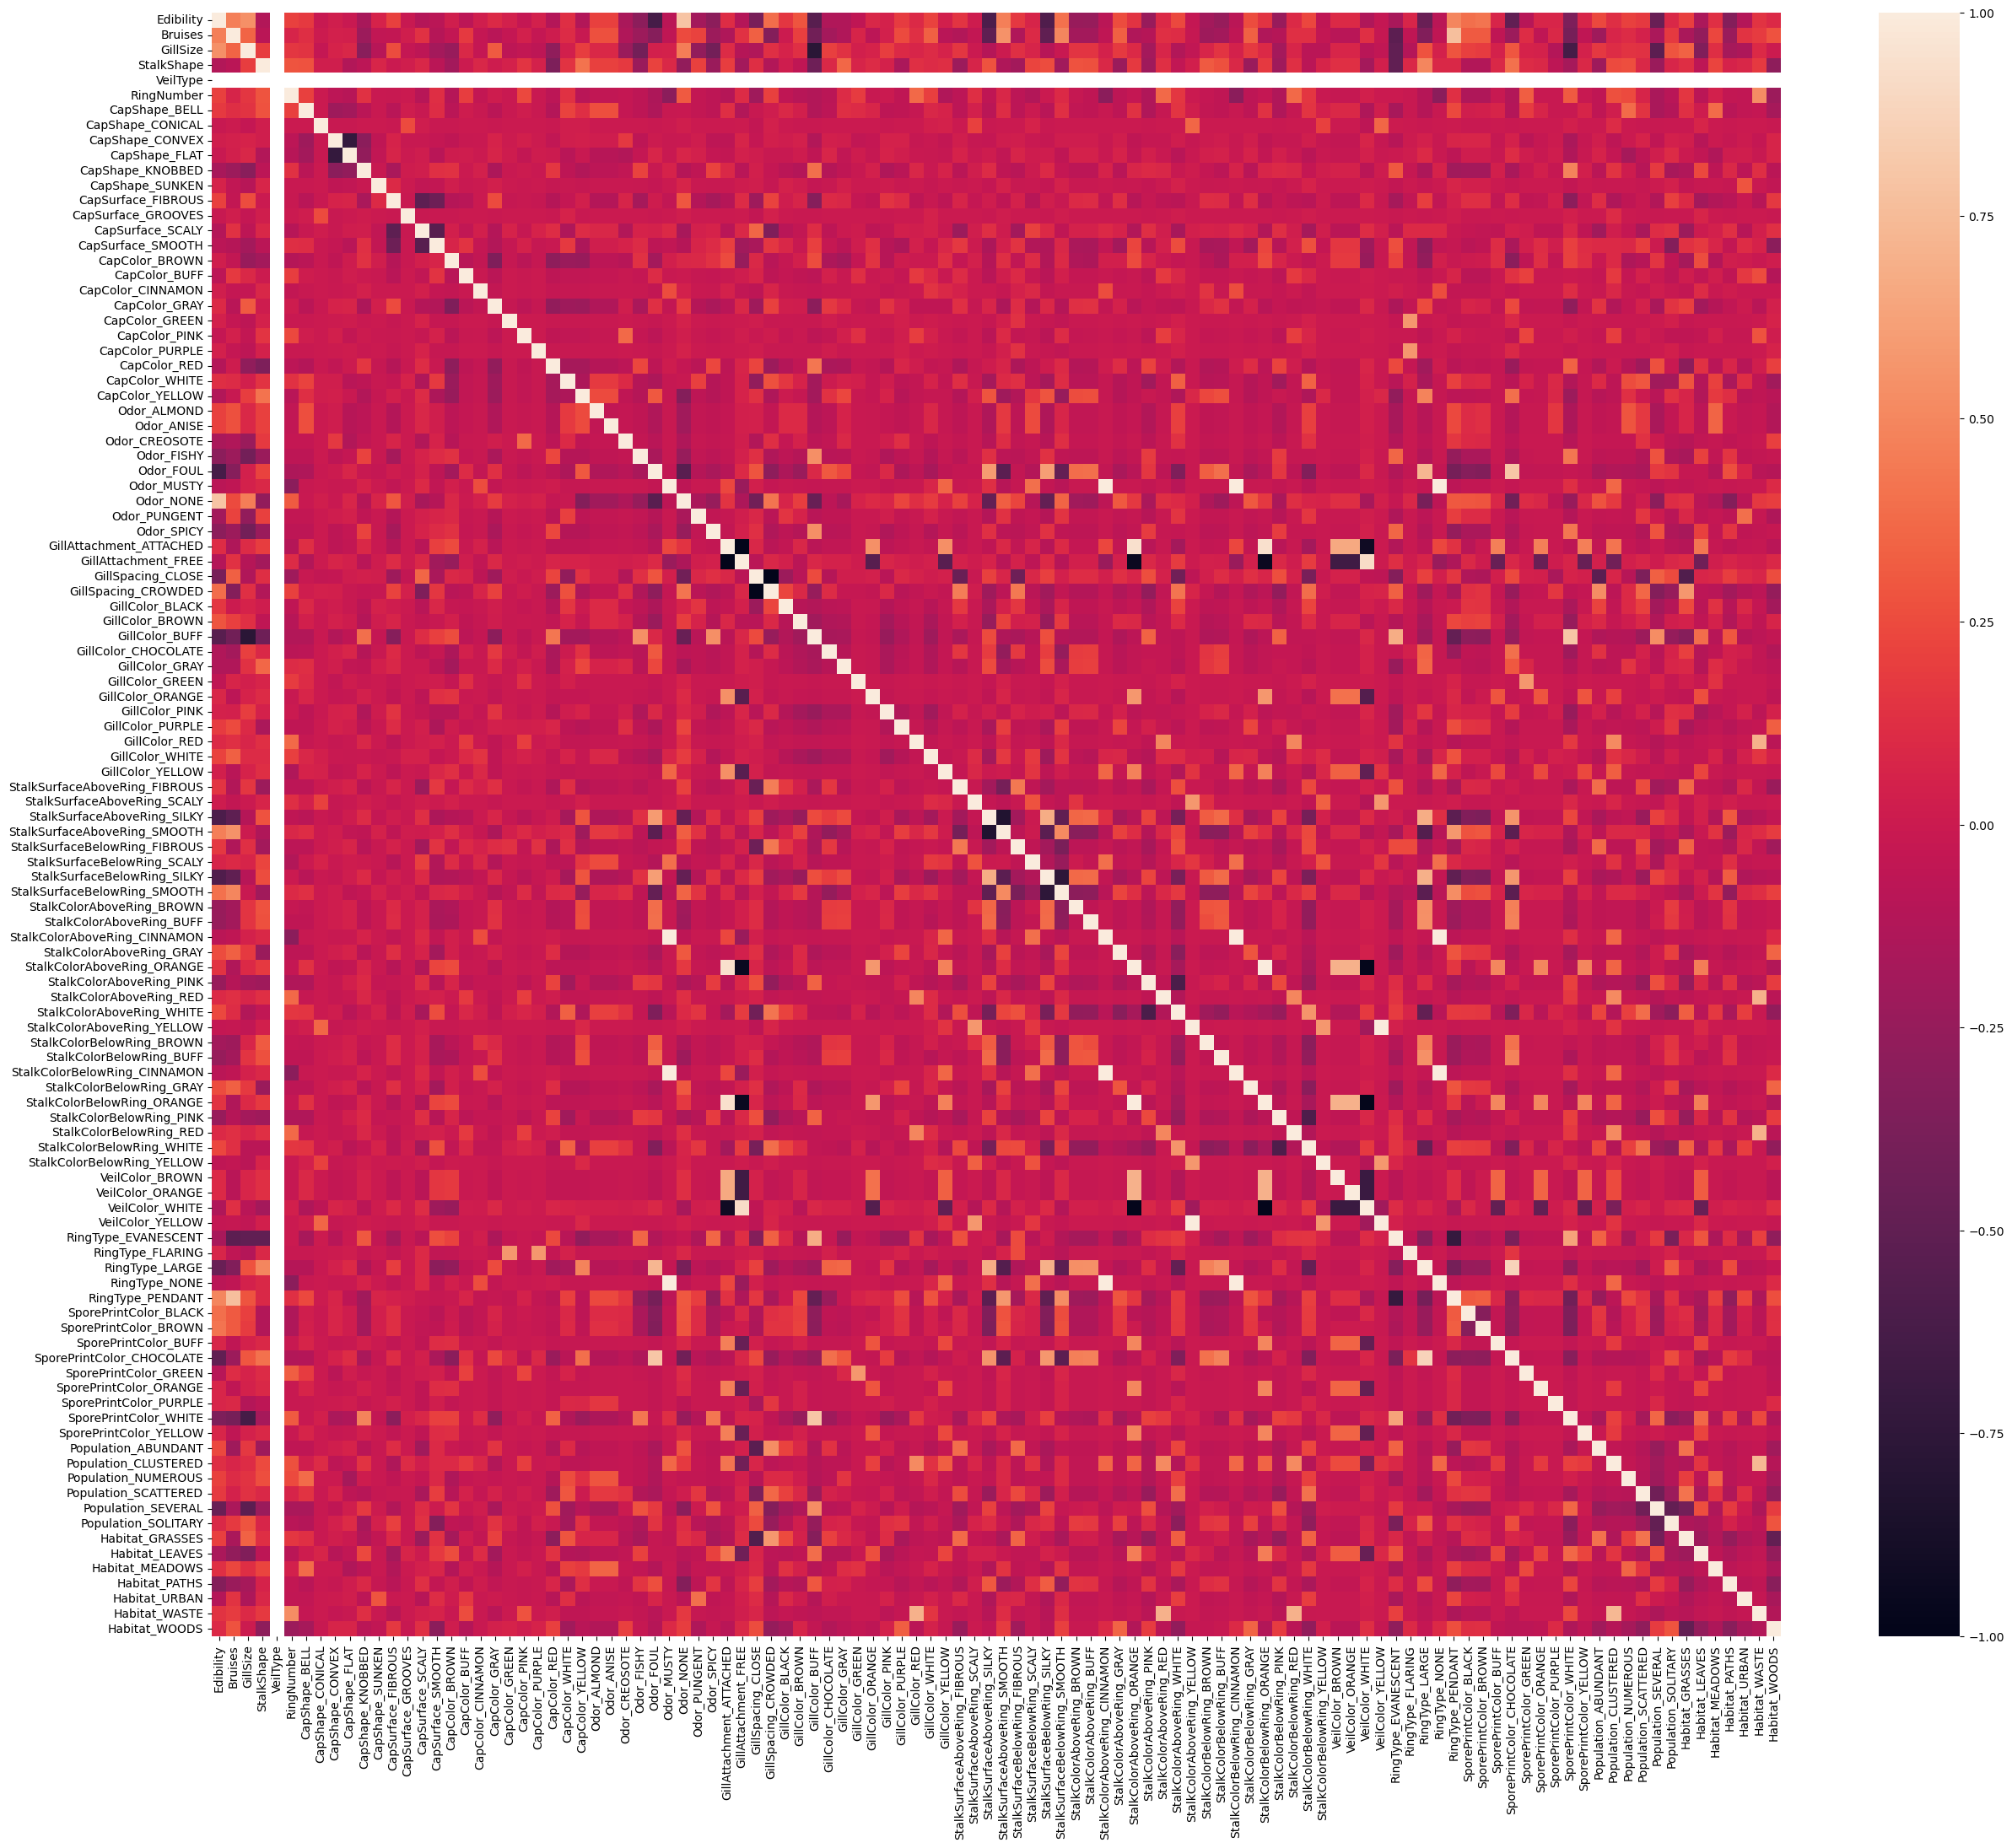


ModeImputed


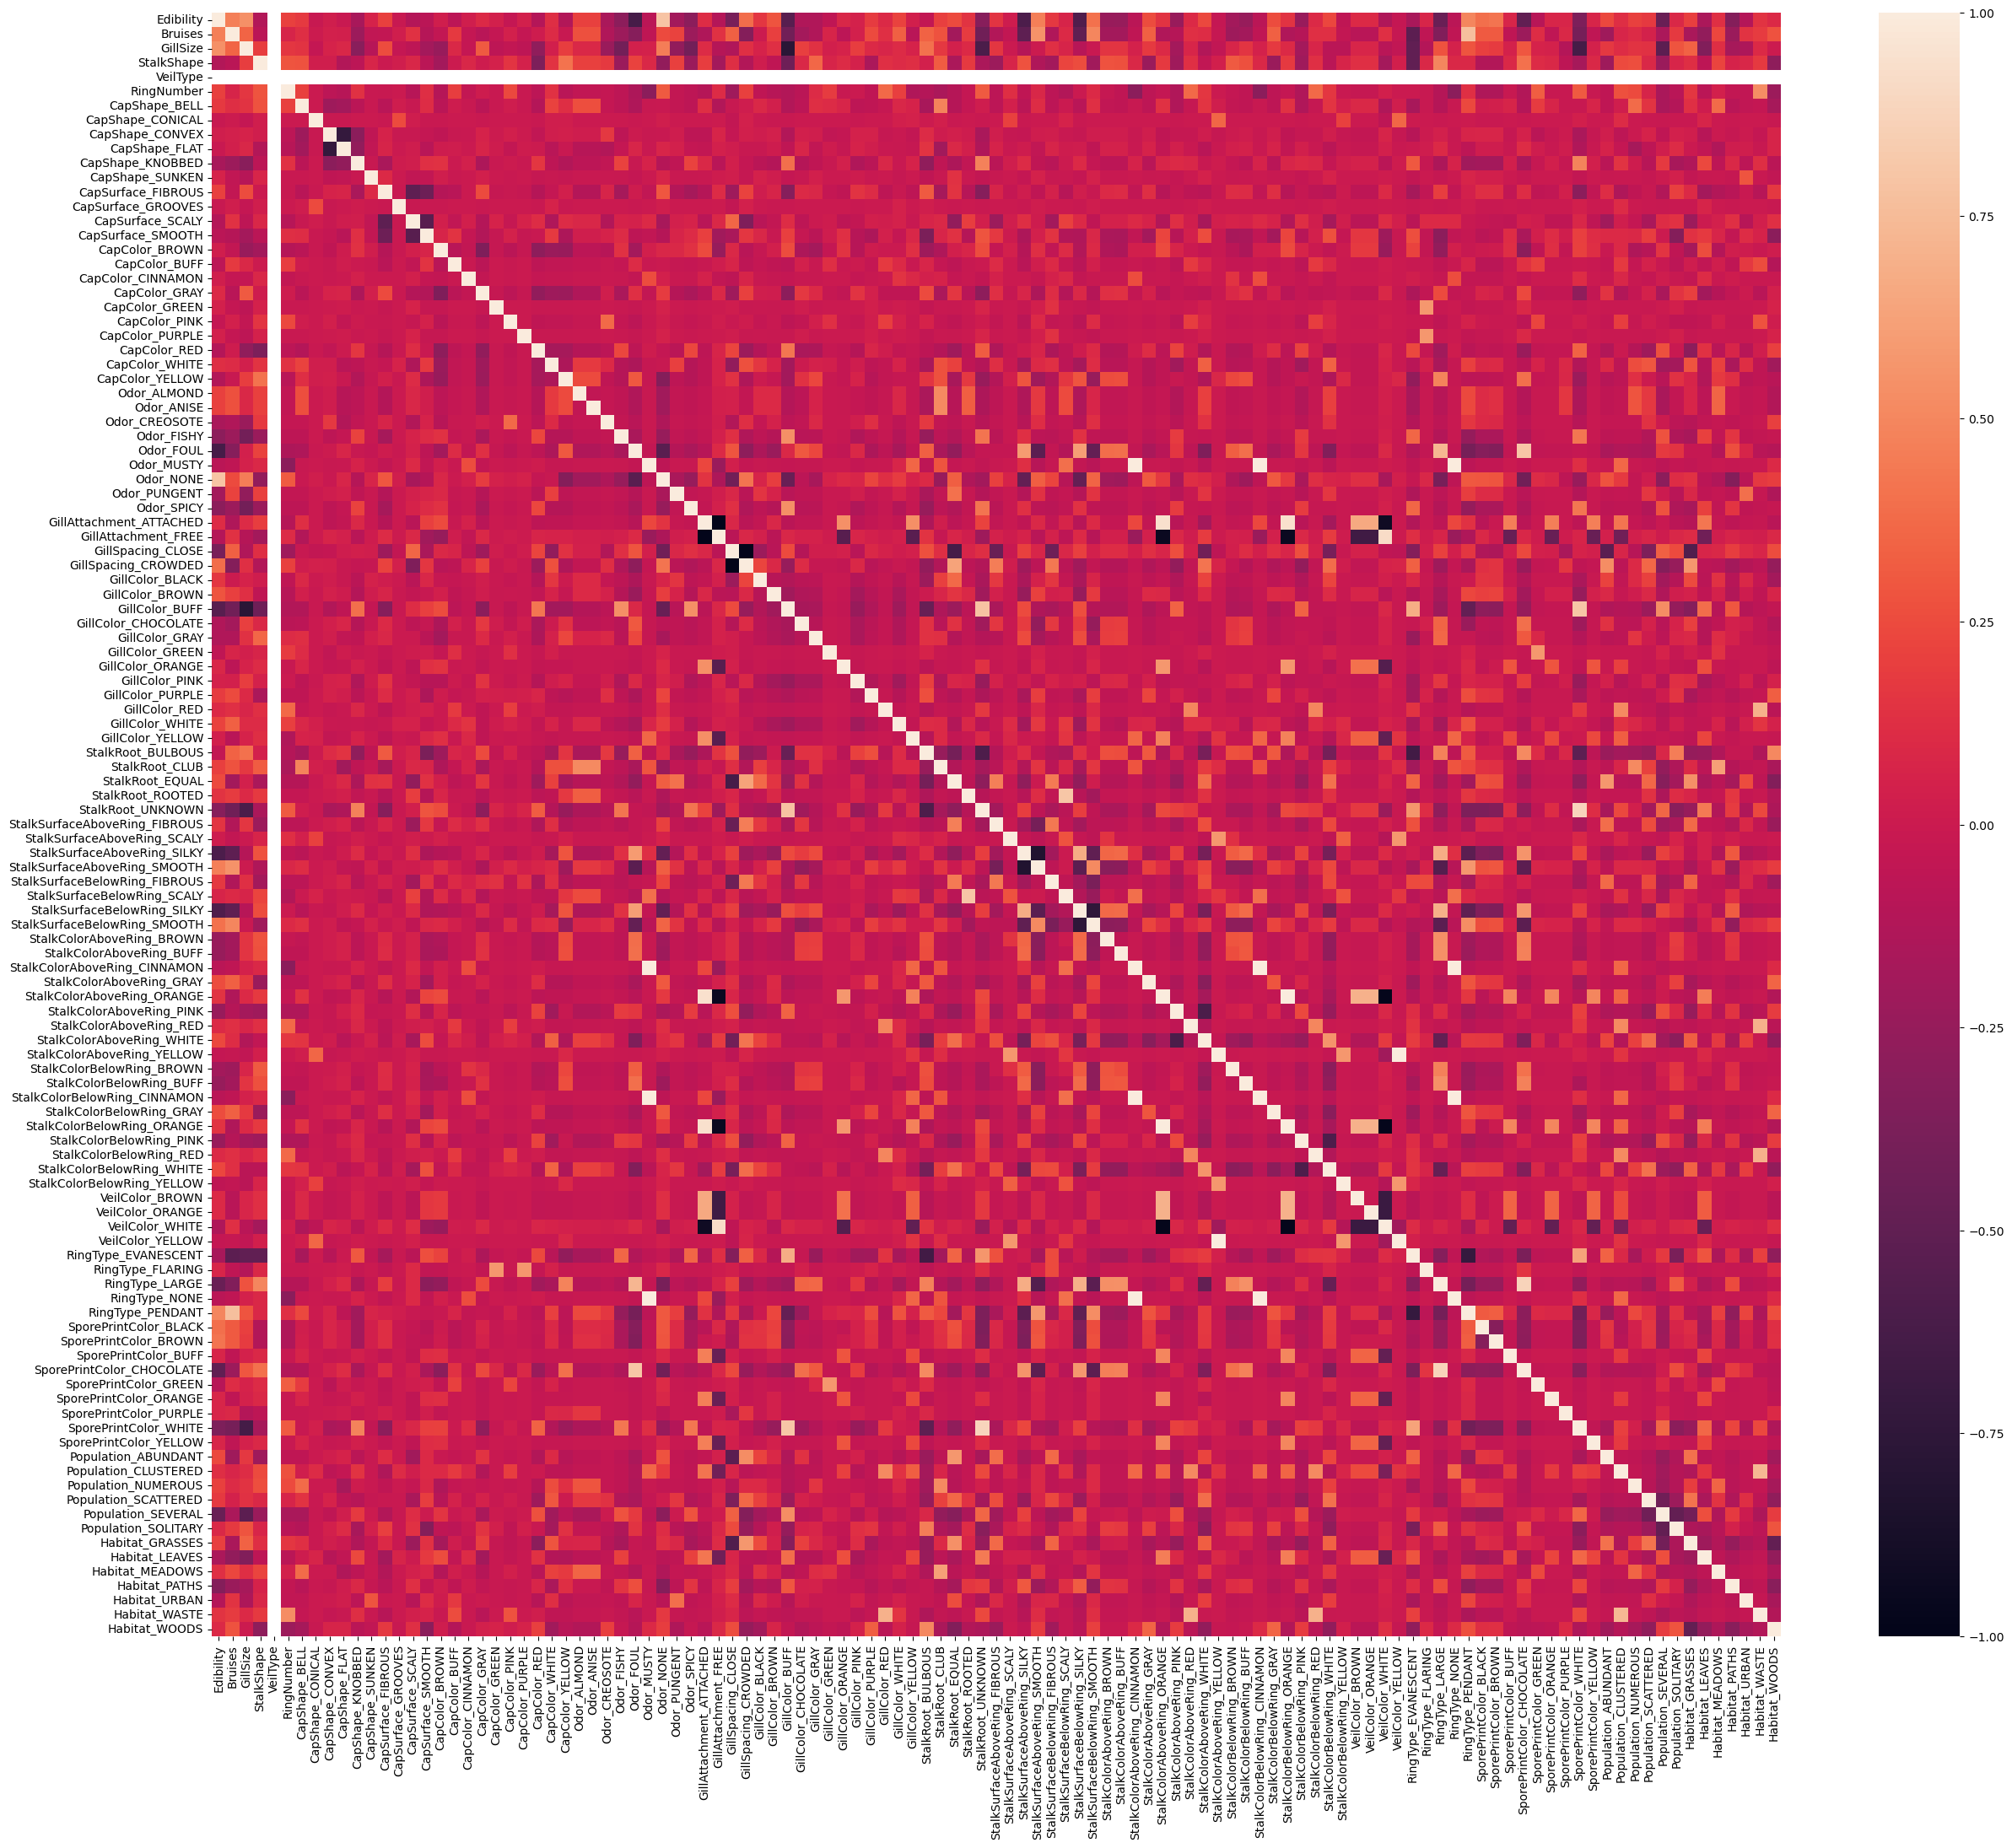

In [13]:
print("Heatmap Correlation")
print("NullsDropped")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfnullsdropped.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Don't annotate because there's too many numbers for them to be meaningful individually.
pyplot.show()
print("")
print("ModeImputed")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfnullsfilled.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Same thing here.
pyplot.show()
print("")

The heatmaps are relatively humongous, due to all the one-hot-encoding columns we've added; the amount of data here is too much for me to properly analyze closely, but I can express a few big picture insights.

One, the overall heatmap is very 0.0 correlation red; I expect this is a good sign, as low correlation means each feature is encoding different information to the others.

It also appears that many of the correlation spikes, as one might expect, are referring to the one-hot-encoding groups, clustered around the central diagonal line. However, there are also notable correlation spikes around the StalkSurfaceBelowRing x SporePrintColor and VeilColor x GillAttachment groupings, which may be of note later on or if we wanted to choose features to drop from the dataset.

Finally, one row of particular note is of course "Edibility". The features with the highest absolute correlation values were: Bruises, GillSize, Odor_FOUL, Odor_NONE, GillSpacing_CROWDED, GillColor_BROWN, GillColor_BUFF, StalkSurfaceAboveRing_SILKY, StalkSurfaceAboveRing_SMOOTH, StalkSurfaceBelowRing_SILKY, StalkSurfaceBelowRing_SMOOTH, RingType_LARGE, RingType_PENDANT, SporePrintColor_BLACK, SporePrintColor_BROWN, SporePrintColor_CHOCOLATE, SporePrintColor_WHITE, Population_SEVERAL, Habitat_PATHS. These features are the ones that are therefore most likely to be the most helpful in determining edibility; whether a mushroom has an Odor of FOUL or an odor of NONE correlates very strongly to a mushroom's edibility, thereby making Odor a very important feature for determining as much.

Of these, it is of note that several appear in the list of the six features listed as most important by https://www.mecs-press.org/ijigsp/ijigsp-v11-n4/IJIGSP-V11-N4-5.pdf, though not all. In particular, CapColor doesn't seem to have any particularly strong correlations based on this heatmap, which does disagree with the above research paper's assertion.

* #### Prepare Features and Split 
1.  Split your data into training and testing sets, using stratification.

In [14]:
droppedfeatures = dfnullsdropped.drop(columns=["Edibility"])
droppedlabels = dfnullsdropped["Edibility"]

#Split the data into training and testing feature tables, and training and testing label arrays
droppedfeatures_train, droppedfeatures_test, droppedlabels_train, droppedlabels_test = train_test_split(
    droppedfeatures,
    droppedlabels,
    test_size=0.2,
    random_state=42,
    stratify=droppedlabels
)



filledfeatures = dfnullsfilled.drop(columns=["Edibility"])
filledlabels = dfnullsfilled["Edibility"]

#Split the data into training and testing feature tables, and training and testing label arrays
filledfeatures_train, filledfeatures_test, filledlabels_train, filledlabels_test = train_test_split(
    filledfeatures,
    filledlabels,
    test_size=0.2,
    random_state=42,
    stratify=filledlabels
)

print("Completed Calculations")

Completed Calculations


2. Print the shape of all four arrays (X_train, X_test, y_train, y_test). 

In [15]:
print("Split Data:")
print("Dropped")
print(droppedfeatures_train.shape)
print(droppedfeatures_test.shape)
print(droppedlabels_train.shape)
print(droppedlabels_test.shape)
print("")
print("Imputed")
print(filledfeatures_train.shape)
print(filledfeatures_test.shape)
print(filledlabels_train.shape)
print(filledlabels_test.shape)
print("")

Split Data:
Dropped
(6732, 107)
(1684, 107)
(6732,)
(1684,)

Imputed
(6732, 112)
(1684, 112)
(6732,)
(1684,)



3. In a markdown cell, verify that the survival rate is approximately the same in
both splits.

In [16]:
print("Value Counts:")
print("")
print("Dropped")
print(droppedlabels_train.value_counts())
print("Edibility Ratio:", droppedlabels_train.value_counts()[1] /  droppedlabels_train.value_counts()[0])
print(droppedlabels_test.value_counts())
print("Edibility Ratio:", droppedlabels_test.value_counts()[1] /  droppedlabels_test.value_counts()[0])
print("")
print("Imputed")
print(filledlabels_train.value_counts())
print("Edibility Ratio:", filledlabels_train.value_counts()[1] /  filledlabels_train.value_counts()[0])
print(filledlabels_test.value_counts())
print("Edibility Ratio:", filledlabels_test.value_counts()[1] /  filledlabels_test.value_counts()[0])
print("")

Value Counts:

Dropped
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447

Imputed
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447



The survival ratio is effectively the same for both sets, so the stratification worked nicely.

4. Verify that all features are numerical by printing X_train.dtypes. In a 
markdown cell, confirm that no string or Boolean columns remain. If any do, fix them 
now and explain what you have changed. 

In [17]:
print("Types:")
print("Dropped")
print(dfnullsdropped.dtypes)
print("")
print("Imputed")
print(dfnullsfilled.dtypes)
print("")

Types:
Dropped
Edibility                        object
Bruises                          object
GillSize                         object
StalkShape                       object
VeilType                         object
RingNumber                       object
CapShape_BELL                     int64
CapShape_CONICAL                  int64
CapShape_CONVEX                   int64
CapShape_FLAT                     int64
CapShape_KNOBBED                  int64
CapShape_SUNKEN                   int64
CapSurface_FIBROUS                int64
CapSurface_GROOVES                int64
CapSurface_SCALY                  int64
CapSurface_SMOOTH                 int64
CapColor_BROWN                    int64
CapColor_BUFF                     int64
CapColor_CINNAMON                 int64
CapColor_GRAY                     int64
CapColor_GREEN                    int64
CapColor_PINK                     int64
CapColor_PURPLE                   int64
CapColor_RED                      int64
CapColor_WHITE           

As can be seen above, all of the columns remaining are int64 types, as intended.

### HELPERS




In [18]:

#result table for future proof
results = pd.DataFrame(columns=[
    "Model",
    "Preprocessing",
    "Hyperparameters",
    "CV Mean",
    "CV Std",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Training Time (s)",
    "Notes"
])

results


#Function to add results to the results DataFrame
def add_result(results_df, model_name, preprocessing_name, hyperparameters,
               cv_mean, cv_std, test_accuracy, test_precision,
               test_recall, test_f1, training_time, notes=""):
    
    results_df.loc[len(results_df)] = {
        "Model": model_name,
        "Preprocessing": preprocessing_name,
        "Hyperparameters": str(hyperparameters),
        "CV Mean": cv_mean,
        "CV Std": cv_std,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
        "Training Time (s)": training_time,
        "Notes": notes
    }
    
    return results_df


#Function to evaluate a model and return the relevant metrics
def evaluate_model(model, X_train, X_test, y_train, y_test):
    start_time = time.time()
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    training_time = time.time() - start_time
    
    results = {
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "Training Time (s)": training_time
    }
    
    return results, y_pred

## Random Forest

For the Random Forest section, we will use **one single preprocessing pipeline** and make the model itself more sophisticated.
### Workflow:
1. train a baseline model
2. Run RandomizedSearchCV for inital hyperparameter search
3. Run GridSearchCV to refine the search near the strongest settings
4. Evaluate using N-fold CV
5. Inspect
### Why this approach?
Random Forest is a strong choice for this dataset because:
- the data is mostly categorical and has already been encoded numerically
- Random Forest handles nonlinear feature interactions well

Because the mushroom dataset is known to be highly structured, it is possible for tree-based models to achieve extremely high performance. For that reason, the goal of tuning here is not only to improve the score, but also to check whether performance remains stable across different hyperparameter settings.


In [19]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

rf_X_train = filledfeatures_train.copy()
rf_X_test = filledfeatures_test.copy()

rf_y_train = pd.Series(filledlabels_train).astype(int)
rf_y_test = pd.Series(filledlabels_test).astype(int)
rf_preprocessing_name = "Filled StalkRoot"

baseline_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
#Evaluate the baseline model and add results to the results DataFrame
baseline_metrics, baseline_y_pred = evaluate_model(
    baseline_rf,
    rf_X_train, rf_X_test,
    rf_y_train, rf_y_test
)
results = add_result(
    results,
    model_name="Random Forest (Baseline)",
    preprocessing_name=rf_preprocessing_name,
    hyperparameters=baseline_rf.get_params(),
    cv_mean=baseline_metrics["CV Mean"],
    cv_std=baseline_metrics["CV Std"],
    test_accuracy=baseline_metrics["Test Accuracy"],
    test_precision=baseline_metrics["Test Precision"],
    test_recall=baseline_metrics["Test Recall"],
    test_f1=baseline_metrics["Test F1"],
    training_time=baseline_metrics["Training Time (s)"],
    notes="Default Random Forest used as the baseline."
)

print("Baseline Results:")
print(baseline_metrics)

#RandomizedSearchCV
random_param_dist = {
    "n_estimators": [100, 200, 300, 500], #Exploring a range of values for n_estimators to find a good balance between performance and training time, given the dataset size and complexity
    "max_depth": [None, 10, 20, 30, 40], #None is included to allow for fully grown trees, but we also want to explore some reasonable depth limits given the dataset size and complexity
    "min_samples_split": [2, 5, 10], #Focusing on smaller values for min_samples_split since larger values would likely underfit given the dataset size and complexity
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=random_param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy", #using accuracy for now
    random_state=42,
    n_jobs=-1
)

random_start = time.time()
random_search.fit(rf_X_train, rf_y_train)
random_time = time.time() - random_start

random_best_rf = random_search.best_estimator_
random_y_pred = random_best_rf.predict(rf_X_test)

random_metrics = {
    "CV Mean": random_search.best_score_,
    "CV Std": np.nan,
    "Test Accuracy": accuracy_score(rf_y_test, random_y_pred),
    "Test Precision": precision_score(rf_y_test, random_y_pred),
    "Test Recall": recall_score(rf_y_test, random_y_pred),
    "Test F1": f1_score(rf_y_test, random_y_pred),
    "Training Time (s)": random_time
}

results = add_result(
    results,
    model_name="Random Forest (RandomizedSearchCV)",
    preprocessing_name=rf_preprocessing_name,
    hyperparameters=random_search.best_params_,
    cv_mean=random_metrics["CV Mean"],
    cv_std=random_metrics["CV Std"],
    test_accuracy=random_metrics["Test Accuracy"],
    test_precision=random_metrics["Test Precision"],
    test_recall=random_metrics["Test Recall"],
    test_f1=random_metrics["Test F1"],
    training_time=random_metrics["Training Time (s)"],
    notes="Broad hyperparameter search using RandomizedSearchCV."
)

print("\nBest RandomizedSearchCV Parameters:")
print(random_search.best_params_)
print("Best RandomizedSearchCV CV Score:", random_search.best_score_)
print("RandomizedSearchCV Test Metrics:")
print(random_metrics)

#Finetuning with GridSearchCV
random_best_params = random_search.best_params_


#Helper function to get a focused range of candidates around the best value
def around_center(value, candidates):
    if value not in candidates:
        return candidates
    idx = candidates.index(value)
    left = max(0, idx - 1)
    right = min(len(candidates), idx + 2)
    return candidates[left:right]

n_estimator_candidates = sorted(set(around_center(random_best_params["n_estimators"], [100, 200, 300, 500])))
max_depth_candidates = sorted(set(around_center(random_best_params["max_depth"], [10, 20, 30, 40]) if random_best_params["max_depth"] is not None else [None, 20, 30]))
min_split_candidates = sorted(set(around_center(random_best_params["min_samples_split"], [2, 5, 10])))
min_leaf_candidates = sorted(set(around_center(random_best_params["min_samples_leaf"], [1, 2, 4])))

grid_param_grid = {
    "n_estimators": n_estimator_candidates,
    "max_depth": max_depth_candidates, #None is included if it was the best value, otherwise we focus around the best non-None value
    "min_samples_split": min_split_candidates,#Same thing here, focus around the best value from RandomizedSearchCV
    "min_samples_leaf": min_leaf_candidates,
    "max_features": [random_best_params["max_features"]],
    "bootstrap": [random_best_params["bootstrap"]]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=grid_param_grid, 
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_start = time.time()
grid_search.fit(rf_X_train, rf_y_train)
grid_time = time.time() - grid_start

best_rf = grid_search.best_estimator_
best_y_pred = best_rf.predict(rf_X_test)

best_rf_metrics = {
    "CV Mean": grid_search.best_score_,
    "CV Std": np.nan,
    "Test Accuracy": accuracy_score(rf_y_test, best_y_pred),
    "Test Precision": precision_score(rf_y_test, best_y_pred),
    "Test Recall": recall_score(rf_y_test, best_y_pred),
    "Test F1": f1_score(rf_y_test, best_y_pred),
    "Training Time (s)": grid_time
}

results = add_result(
    results,
    model_name="Random Forest (Focused GridSearchCV)",
    preprocessing_name=rf_preprocessing_name,
    hyperparameters=grid_search.best_params_,
    cv_mean=best_rf_metrics["CV Mean"],
    cv_std=best_rf_metrics["CV Std"],
    test_accuracy=best_rf_metrics["Test Accuracy"],
    test_precision=best_rf_metrics["Test Precision"],
    test_recall=best_rf_metrics["Test Recall"],
    test_f1=best_rf_metrics["Test F1"],
    training_time=best_rf_metrics["Training Time (s)"],
    notes="Focused GridSearchCV refinement around the strongest randomized-search settings."
)

best_y_test = rf_y_test
best_feature_names = rf_X_train.columns

print("\nBestGridSearchCV Parameters:")
print(grid_search.best_params_)
print("Best GridSearchCV CV Score:", grid_search.best_score_)
print("GridSearchCV Test Metrics:")
print(best_rf_metrics)


Baseline Results:
{'CV Mean': np.float64(1.0), 'CV Std': np.float64(0.0), 'Test Accuracy': 1.0, 'Test Precision': 1.0, 'Test Recall': 1.0, 'Test F1': 1.0, 'Training Time (s)': 0.9289021492004395}

Best RandomizedSearchCV Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
Best RandomizedSearchCV CV Score: 1.0
RandomizedSearchCV Test Metrics:
{'CV Mean': np.float64(1.0), 'CV Std': nan, 'Test Accuracy': 1.0, 'Test Precision': 1.0, 'Test Recall': 1.0, 'Test F1': 1.0, 'Training Time (s)': 14.614701509475708}

BestGridSearchCV Parameters:
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best GridSearchCV CV Score: 1.0
GridSearchCV Test Metrics:
{'CV Mean': np.float64(1.0), 'CV Std': nan, 'Test Accuracy': 1.0, 'Test Precision': 1.0, 'Test Recall': 1.0, 'Test F1': 1.0, 'Training Time (s)': 21.89729905128479}


### Random Forest Results

The table below compares the three stages of the same Random Forest pipeline:

1. **Baseline model** — the default Random Forest used as a starting point.
2. **RandomizedSearchCV** — a broader search across many possible hyperparameter combinations.
3. **Focused GridSearchCV** — a smaller refinement search centered around the strongest randomized-search result.


In this notebook, all three stages achieved the same perfect classification performance. That means the baseline model had already reached the performance ceiling on this dataset. Even though tuning did not increase accuracy, it still added value by showing that the model's performance was **stable and robust** across different settings rather than depending on one lucky parameter choice.


In [20]:
rf_results = results[results["Model"].str.contains("Random Forest")].copy()
rf_results = rf_results.sort_values(
    by=["Test Accuracy", "CV Mean", "Test F1"],
    ascending=False
).reset_index(drop=True)

rf_results

,Model,Preprocessing,Hyperparameters,CV Mean,CV Std,...,Test Precision,Test Recall,Test F1,Training Time (s),Notes
0,Random Forest (B...,Filled StalkRoot,{'bootstrap': Tr...,1.0,0.0,...,1.0,1.0,1.0,0.928902,Default Random F...
1,Random Forest (R...,Filled StalkRoot,{'n_estimators':...,1.0,NaN,...,1.0,1.0,1.0,14.614702,Broad hyperparam...
2,Random Forest (F...,Filled StalkRoot,{'bootstrap': Tr...,1.0,NaN,...,1.0,1.0,1.0,21.897299,Focused GridSear...


### Interpreting the Perfect Scores

A score of **1.0** across cross-validation and the test set can look suspicious at first, so it is important to interpret it carefully.

This result does not automatically means overfitting. Especially in this case:
- the cross-validation mean is also 1.0,
- the cross-validation standard deviation is 0.0,
- the held-out test set accuracy, precision, recall, and F1-score are also 1.0.

These results suggest that the mushroom dataset is **highly separable** for tree-based methods, not that the model is simply memorizing the training data.

This result also does **not strongly suggest leakage**. Although some preprocessing steps were done before splitting, those steps were label independent transformations such as one-hot encoding and missing-value handling. Since the model also performs perfectly under cross-validation on the training set and on the separate test set, there is no clear evidence that leakage is driving the result.

### Final Tuned Random Forest Model
Now we will inspect that final tuned model in more detail using:
1. the best hyperparameters
2. the classification report
3. the confusion matrix
4. feature importances


This step moves beyond overall accuracy and helps show **how** the model is making its decisions. Since the model achieved perfect scores, these diagnostics mainly serve as validation and interpretation rather than error analysis.


In [21]:
final_rf_summary = pd.DataFrame([{
    "Preprocessing": rf_preprocessing_name,
    "Best CV Mean": grid_search.best_score_,
    "Test Accuracy": best_rf_metrics["Test Accuracy"],
    "Test Precision": best_rf_metrics["Test Precision"],
    "Test Recall": best_rf_metrics["Test Recall"],
    "Test F1": best_rf_metrics["Test F1"],
    "Best Params": grid_search.best_params_
}])

final_rf_summary


print("Final Classification Report:")
print(classification_report(best_y_test, best_y_pred, target_names=["Poisonous", "Edible"]))


Final Classification Report:
              precision    recall  f1-score   support

   Poisonous       1.00      1.00      1.00       786
      Edible       1.00      1.00      1.00       898

    accuracy                           1.00      1684
   macro avg       1.00      1.00      1.00      1684
weighted avg       1.00      1.00      1.00      1684



### Confusion Matrix and Feature Importance Interpretation

The confusion matrix shows whether the model made any mistakes on the held-out test set. In this notebook, the matrix should show all predictions on the diagonal and zeros elsewhere, which confirms that every test sample was classified correctly.

The feature-importance table highlights which encoded mushroom characteristics contributed most to the model's decisions. These values do **not** prove causation, but they do help identify which attributes were most useful for separating edible from poisonous mushrooms in this dataset.

In [25]:
# Confusion matrix
cm = confusion_matrix(best_y_test, best_y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Poisonous", "Actual Edible"],
    columns=["Predicted Poisonous", "Predicted Edible"]
)

print("Confusion Matrix:")
display(cm_df)


# Feature importances
feature_importances = pd.DataFrame({
    "Feature": best_feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 15 Most Important Features:")
display(feature_importances.head(15))

print("Train Accuracy:", best_rf.score(rf_X_train, rf_y_train))
print("Test Accuracy:", best_rf.score(rf_X_test, rf_y_test))

Confusion Matrix:


,Predicted Poisonous,Predicted Edible
Actual Poisonous,786,0
Actual Edible,0,898


Top 15 Most Important Features:


,Feature,Importance
31,Odor_NONE,0.623452
51,StalkRoot_CLUB,0.151887
60,StalkSurfaceBelo...,0.052230
53,StalkRoot_ROOTED,0.037152
94,SporePrintColor_...,0.032326
0,Bruises,0.022825
26,Odor_ANISE,0.016975
25,Odor_ALMOND,0.016717
52,StalkRoot_EQUAL,0.004883
96,SporePrintColor_...,0.004419


Train Accuracy: 1.0
Test Accuracy: 1.0


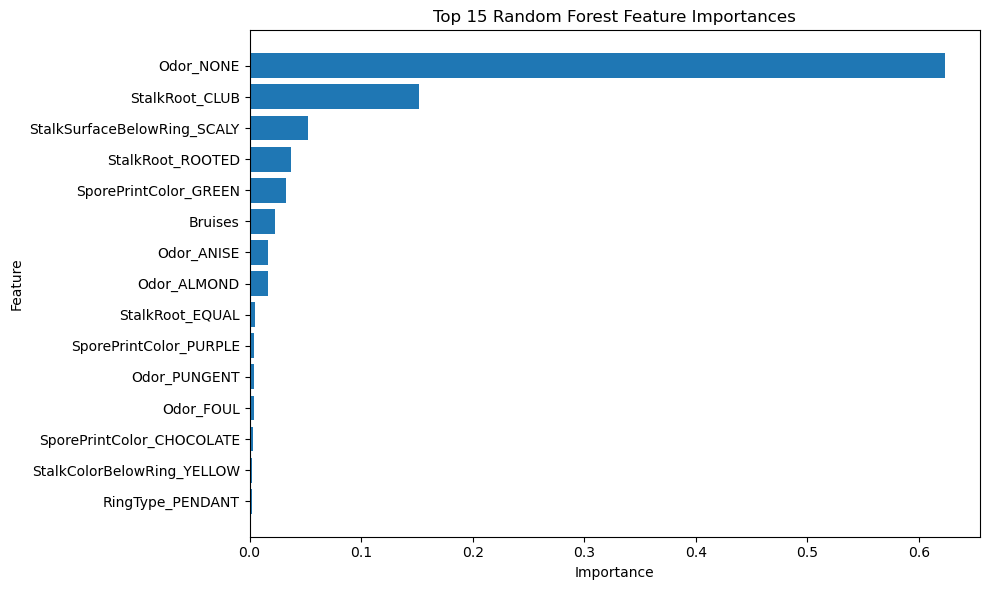

In [ ]:
# Plot top 15 feature importances
top_n = 15
top_features = feature_importances.head(top_n).sort_values("Importance", ascending=True)

pyplot.figure(figsize=(10, 6))
pyplot.barh(top_features["Feature"], top_features["Importance"])
pyplot.xlabel("Importance")
pyplot.ylabel("Feature")
pyplot.title("Top 15 Random Forest Feature Importances")
pyplot.tight_layout()
pyplot.show()

oob_rf = RandomForestClassifier(
    **grid_search.best_params_,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

oob_rf.fit(rf_X_train, rf_y_train)
print("OOB Score:", oob_rf.oob_score_)

OOB Score: 1.0


### Random Forest Conclusion

Random Forest performed extremely well on this mushroom classification task. The baseline model already achieved perfect results, and both hyperparameter-tuning stages confirmed that this performance was consistent across multiple configurations.

Because the cross-validation scores and test-set scores were both perfect, the most reasonable conclusion is that the dataset is highly separable for this type of model. In other words, the final story is **not** that tuning dramatically improved the model, but that tuning helped confirm the **robustness and reliability** of the Random Forest approach on this dataset.

If this project were extended further, a useful next step would be to test the model on a more difficult mushroom dataset or on a multiclass species-label dataset, where model differences would likely be easier to observe.


## Feature Ablation Study: Removing `Odor`

Because all of the main Random Forest runs reached perfect performance, it is useful to test whether the models are relying too heavily on one especially informative feature. In mushroom classification, **odor** is often one of the strongest predictors of edibility, so we remove it on purpose and rerun all three models.

### Goal of this section
- evaluate the three models on the normal filled dataset
- create a separate copy with all `Odor`-related columns removed
- rerun the same models on the odor-ablated version
- compare how much performance changes

This is **not** meant to improve the model. Instead, it helps answer whether the dataset is still easy to classify when a major feature is removed, and whether performance depends too heavily on odor alone.


In [ ]:
# Identify all one-hot encoded odor columns and create an odor-ablated copy
odor_columns = [col for col in filledfeatures.columns if col == "Odor" or col.startswith("Odor_")]

print("Odor-related columns found:", len(odor_columns))
print(odor_columns)

original_X_train = filledfeatures_train.copy()
original_X_test = filledfeatures_test.copy()

no_odor_X_train = filledfeatures_train.drop(columns=odor_columns).copy()
no_odor_X_test = filledfeatures_test.drop(columns=odor_columns).copy()

y_train_ablation = pd.Series(filledlabels_train).astype(int)
y_test_ablation = pd.Series(filledlabels_test).astype(int)

print("
Original training shape:", original_X_train.shape)
print("Original testing shape:", original_X_test.shape)
print("No-odor training shape:", no_odor_X_train.shape)
print("No-odor testing shape:", no_odor_X_test.shape)


### Models used in the ablation study

To keep the comparison fair, we use the same train/test split and evaluate each model in the same way on both feature sets:

- **Decision Tree** as a simple interpretable tree-based baseline
- **AdaBoost** as an ensemble method that combines many weak learners
- **Random Forest** using the strongest settings found earlier in the notebook

If the scores stay high after removing odor, that suggests the dataset contains **redundant predictive information**. If the scores drop sharply, that suggests **odor carries a large share of the classification power**.


In [ ]:
def run_ablation_experiment(model_name, model, X_train, X_test, y_train, y_test, feature_set_name):
    metrics, y_pred = evaluate_model(model, X_train, X_test, y_train, y_test)
    return {
        "Model": model_name,
        "Feature Set": feature_set_name,
        "CV Mean": metrics["CV Mean"],
        "CV Std": metrics["CV Std"],
        "Test Accuracy": metrics["Test Accuracy"],
        "Test Precision": metrics["Test Precision"],
        "Test Recall": metrics["Test Recall"],
        "Test F1": metrics["Test F1"],
        "Training Time (s)": metrics["Training Time (s)"]
    }

ablation_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        **grid_search.best_params_,
        random_state=42,
        n_jobs=-1
    )
}

ablation_rows = []

for model_name, model in ablation_models.items():
    ablation_rows.append(
        run_ablation_experiment(
            model_name,
            model,
            original_X_train, original_X_test,
            y_train_ablation, y_test_ablation,
            "All Features"
        )
    )

for model_name, model in ablation_models.items():
    ablation_rows.append(
        run_ablation_experiment(
            model_name,
            model,
            no_odor_X_train, no_odor_X_test,
            y_train_ablation, y_test_ablation,
            "Without Odor"
        )
    )

ablation_results = pd.DataFrame(ablation_rows)
ablation_results = ablation_results.sort_values(by=["Model", "Feature Set"]).reset_index(drop=True)
ablation_results


### Interpreting the ablation results

This table should be read as a **before vs after** comparison:

- **All Features** = the normal encoded dataset
- **Without Odor** = the same dataset after removing all odor-related columns

Key interpretation ideas:

- If a model stays near **1.0**, then other features still provide enough signal to classify edibility accurately.
- If a model drops noticeably, then odor was one of the most important sources of predictive information.
- If all three models drop, that strengthens the claim that odor is globally important for this task rather than only important for one specific model.


In [ ]:
ablation_pivot = ablation_results.pivot(index="Model", columns="Feature Set", values="Test Accuracy")
ablation_pivot["Accuracy Drop"] = ablation_pivot["All Features"] - ablation_pivot["Without Odor"]
ablation_pivot = ablation_pivot.reset_index()

ablation_pivot


In [ ]:
# Visual comparison of test accuracy before and after odor removal
plot_df = ablation_results[["Model", "Feature Set", "Test Accuracy"]].copy()

pyplot.figure(figsize=(8, 5))
seaborn.barplot(data=plot_df, x="Model", y="Test Accuracy", hue="Feature Set")
pyplot.title("Model Accuracy Before and After Removing Odor")
pyplot.ylim(0, 1.05)
pyplot.tight_layout()
pyplot.show()


### Ablation takeaway

This feature ablation test gives a stronger answer than accuracy alone. Even if the original models all perform perfectly, removing odor shows whether the models are solving the task using a broad set of features or leaning heavily on one dominant predictor.

This also helps address two earlier concerns:

- **Overfitting:** if performance remains strong across multiple models and after feature removal, that supports the idea that the dataset itself is highly separable.
- **Leakage concerns:** if perfect performance were caused only by one suspicious feature, removing that feature would likely collapse performance. If the models still perform well, that suggests the signal is distributed more broadly across the dataset.
